# FITML: Assignment 1, Seoul Bike Rentals
The aim of this first assignment is to predict the number of bike rentals in Seoul at any given moment.

## Preparations (do not change this part)

### Load libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load and preprocess data
- Data is stored in a CSV file
- *parse_dates = [0]* indicates that the first column contains the date
- *date_format* can be used to inform the parser about the format
- *rename* can be used to rename columns and rows

**Hint**: Observe how the chaining of methods works in this example.

In [6]:
data = (pd.read_csv("SeoulBikeData.csv", parse_dates=[0], 
                   date_format = '%d/%m/%Y')
                   .rename(columns = {'Date':'date', 'Rented Bike Count':'count', 'Hour':'hour', 'Temperature(°C)': 'temp',
    'Humidity(%)': 'humidity', 'Wind speed (m/s)': 'wind speed', 'Visibility (10m)':'visibility', 'Dew point temperature(°C)':'dew point',
    'Solar Radiation (MJ/m2)': 'solar radiation', 'Rainfall(mm)': 'rain', 'Snowfall (cm)':'snow', 'Seasons':'season', 'Holiday':'holiday', 'Functioning Day':'workingday'})
)

### Analyze data
The data consists of one row per hour. Columns include the date, the number of rented bikes (count), weather conditions, as well as auxiliary calendar variables (season, holiday, etc).

In [7]:
data.head() # print first 5 rows

,date,count,hour,temp,humidity,wind speed,visibility,dew point,solar radiation,rain,snow,season,holiday,workingday
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [8]:
data.dtypes # print data types

date               datetime64[ns]
count                       int64
hour                        int64
temp                      float64
humidity                    int64
wind speed                float64
visibility                  int64
dew point                 float64
solar radiation           float64
rain                      float64
snow                      float64
season                     object
holiday                    object
workingday                 object
dtype: object

In [9]:
data.describe() # get descriptive statistics of the numeric variables

,date,count,hour,temp,humidity,wind speed,visibility,dew point,solar radiation,rain,snow
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2018-05-31 23:59:59.999999744,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,2018-03-02 00:00:00,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,2018-06-01 00:00:00,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,2018-08-31 00:00:00,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,2018-11-30 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746


In [10]:
data.info() # get info and check whether there are any NAs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             8760 non-null   datetime64[ns]
 1   count            8760 non-null   int64         
 2   hour             8760 non-null   int64         
 3   temp             8760 non-null   float64       
 4   humidity         8760 non-null   int64         
 5   wind speed       8760 non-null   float64       
 6   visibility       8760 non-null   int64         
 7   dew point        8760 non-null   float64       
 8   solar radiation  8760 non-null   float64       
 9   rain             8760 non-null   float64       
 10  snow             8760 non-null   float64       
 11  season           8760 non-null   object        
 12  holiday          8760 non-null   object        
 13  workingday       8760 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(

#### Plot some histograms of all numeric variables excluding date and hour
**Hint**: the *drop* method can be used to drop columns but it only overwrites the original dataframe if *inplace = true* is used. Otherwise it returns the transformed df.

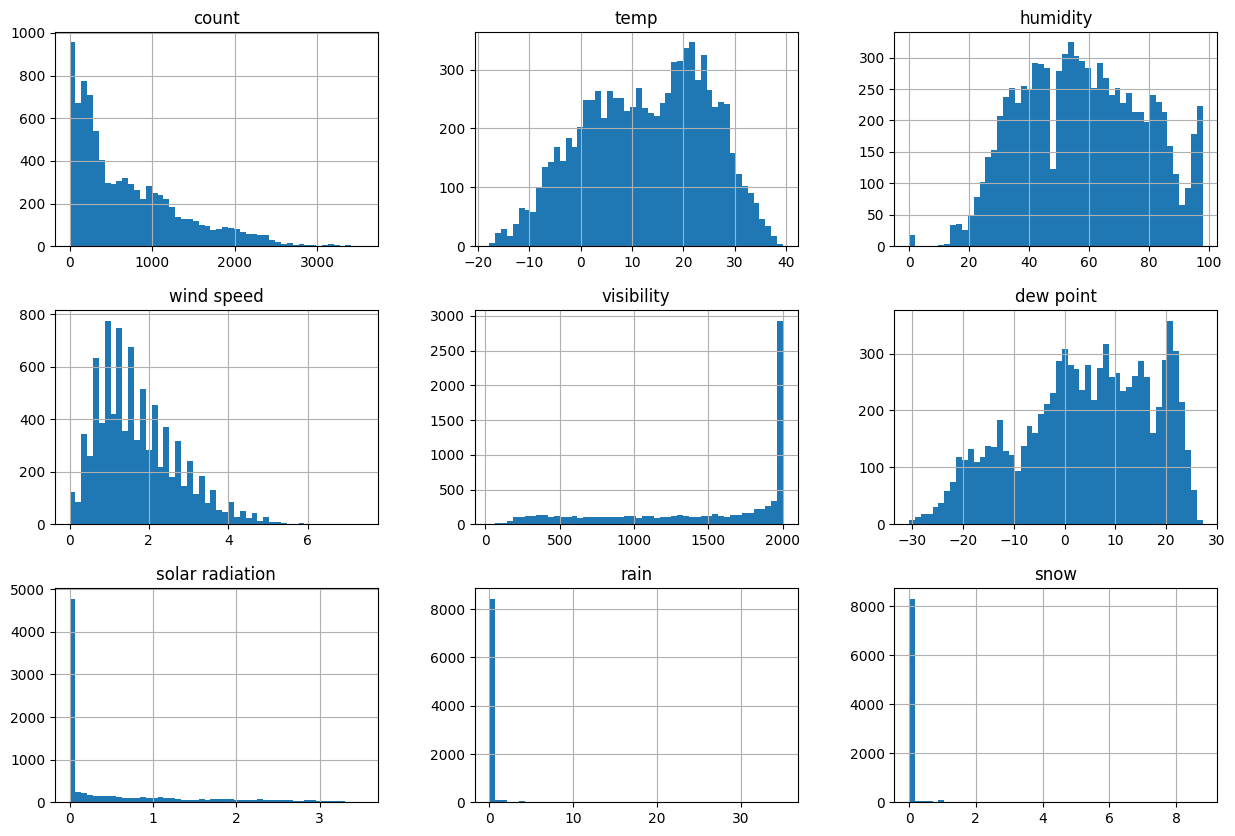

In [11]:
data.drop(["date", "hour"], axis = 1).hist(bins = 50, figsize = (15, 10))
plt.show()

#### Scatterplots of all pairs of numeric variables

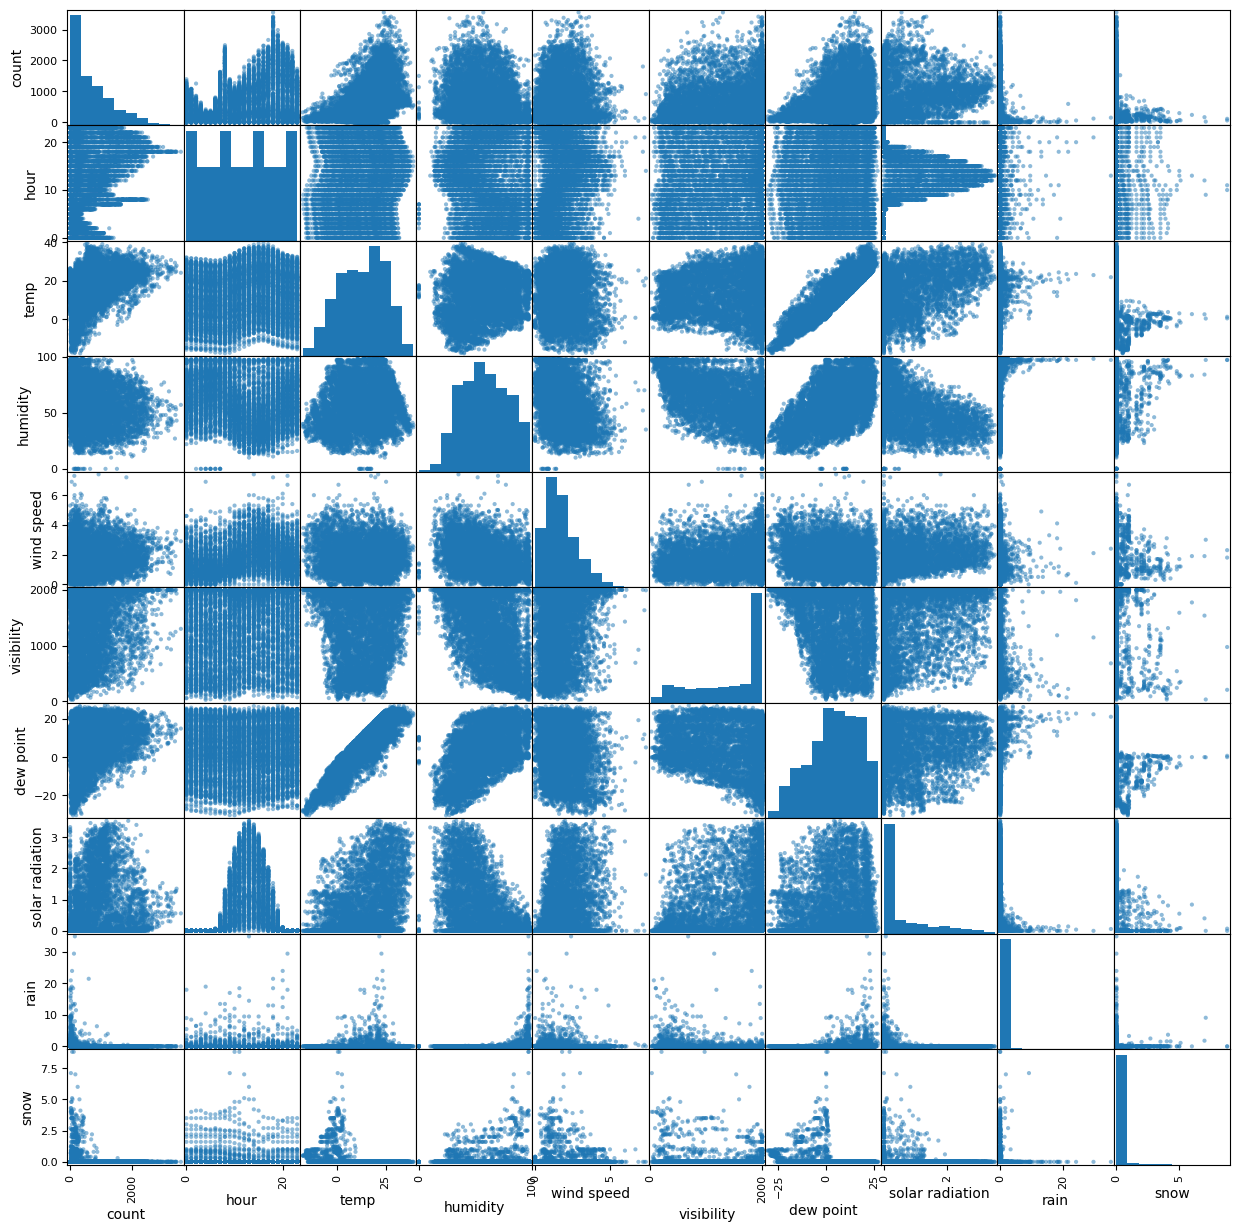

In [12]:
from pandas.plotting import scatter_matrix
scatter_matrix(data.drop(["date"], axis = 1), figsize=(15, 15))
plt.show()

#### Visualize correlations

<Axes: >

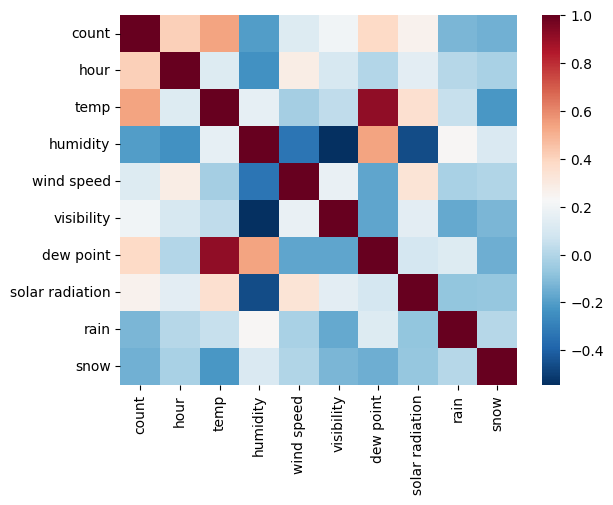

In [13]:
import seaborn as sns
sns.heatmap(data.select_dtypes(include=['number']).corr(),
    xticklabels=data.select_dtypes(include=['number']).columns,
    yticklabels=data.select_dtypes(include=['number']).columns,
    cmap='RdBu_r')

### Set aside a test sample
Since rainfall and snowfall have mostly zeros it would be great to have the same proportion of non-zero entries in the train and test set. For this purpose, we use stratified sampling. However, one can only use one feature to stratify.

In [14]:
print(f"Hours with snowwfall: {len(data[data['snow'] > 0])} ({len(data[data['snow'] > 0]) / data.shape[0] * 100:.2f}%), hours with rain: {len(data[data['rain'] > 0])} ({len(data[data['rain'] > 0]) / data.shape[0] * 100:.2f}%).")

Hours with snowwfall: 443 (5.06%), hours with rain: 528 (6.03%).


In [15]:
num_data = data.select_dtypes(include=['number'])
corr_matrix = num_data.corr()
corr_matrix['snow'].sort_values(ascending=False)

snow               1.000000
humidity           0.108183
rain               0.008500
wind speed        -0.003554
hour              -0.021516
solar radiation   -0.072301
visibility        -0.121695
count             -0.141804
dew point         -0.150887
temp              -0.218405
Name: snow, dtype: float64

In [16]:
corr_matrix['rain'].sort_values(ascending=False)

rain               1.000000
humidity           0.236397
dew point          0.125597
temp               0.050282
hour               0.008715
snow               0.008500
wind speed        -0.019674
solar radiation   -0.074290
count             -0.123074
visibility        -0.167629
Name: rain, dtype: float64

**Decision**: Since snowfall is slightly rarer and has a smaller correlation with other features, we choose the snowfall variable for stratification.

**Reasoning**: Variables with more extreme outliers (e.g., less non-zero values) are less likely to be well represented in a random sample. Features that are less correlated with other features are more likely to have a strong independent effect and should therefore be taken more seriously in stratified sampling.

#### Stratification by clustering
Since the variable snowfall is numeric, classic stratification strategies based on categorical variables fail. In order to convert snowfall into a categorical variable we cluster the feature *snow* into five clusters and use the cluster number as basis for stratification.

In [17]:
from sklearn.cluster import KMeans

# use k-means to cluster snowfall data into 5 clusters
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init = 10).fit(data["snow"].values.reshape(-1, 1))
stratify_clusters = kmeans.labels_
cluster_centers = kmeans.cluster_centers_

# add cluster column to data
data["cluster"] = stratify_clusters

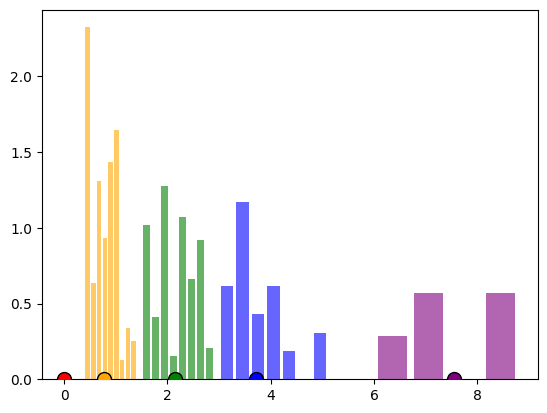

In [18]:
# Plot a histogram of the snowfall and color code the clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']  # Add more colors if needed

x = data["snow"].values
# Plot histograms for each cluster separately
for i in range(1,n_clusters):
    plt.hist(x[stratify_clusters == i], bins='auto', color=colors[i], alpha=0.6, label=f'Cluster {i}', rwidth=0.8, density = True, )

# plot cluster centers
for i, center in enumerate(cluster_centers):
    plt.scatter(center, 0, color=colors[i], s=100, edgecolors='black', zorder=5)  # zorder to place circle above the histogram bars


#### Split the data into training and test sets

In [19]:
from sklearn.model_selection import train_test_split

#training_data, test_data = train_test_split(data, random_state = 42, test_size = 0.2, stratify = stratify_clusters)
training_data, test_data = train_test_split(data, random_state = 42, test_size = 0.2)
training_data_response = training_data[["count"]]
training_data_features = training_data.drop(["count"], axis = 1)
test_data_response = test_data[["count"]]
test_data_features = test_data.drop(["count"], axis = 1)

In [20]:
# save the cluster numbers for the test set for later and drop the cluster numbers from the training and test sets
training_cluster_numbers = training_data_features["cluster"]
training_data_features.drop(["cluster"], axis = 1, inplace = True)
test_data_features.drop(["cluster"], axis = 1, inplace = True)

## Transformations and Feature Engineering
In order to transform our data we will use scikit learn pipelines, which allow to script a well-defined transformations from input data to output data or even to estimated models.

Each step in a pipeline has a fit and a transform method (and possibly also a fit_transform method that first finds the correct parameters of the method and then transforms the data in a single step).

**Hint**: You can change this part as you see fit. Better features might give better (more interpretable) models. The code below is merely a suggestion.

### Add the cumulative snowfall variables to the dataset
Rentals depend on snowfall. However, as opposed to rain, it is plausible that snowfall affects the rentals not only in the time that the snow falls but also in the time afterwards (when the streets are still covered in snow).

In order to add a variable that adds the cumulative snowfall in the recent hours, we define a class of the type BaseEstimator, TransformerMixin.

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin

class SnowFallAdder(BaseEstimator, TransformerMixin):
    def __init__(self, max_lag=6):
        self.max_lag = max_lag

    def fit(self, X, y=None):
        self.original_feature_names_ = X.columns.tolist()
        return self

    def transform(self, X, y=None):
        recent_snow = np.zeros((X.shape[0], self.max_lag))
        for l in range(self.max_lag):
            recent_snow[:, l] = X['snow'].rolling(window=l+1).sum()

        return np.c_[X.values, recent_snow]

    def get_feature_names_out(self, input_features=None):
        # Generate names for the new features
        new_feature_names = [f'cum_snow_{i}' for i in range(self.max_lag)]

        output_feature_names = self.original_feature_names_ + new_feature_names

        return np.array(output_feature_names)

### Define pipeline for numerical attributes
The pipeline consists of a list of transformers that contain tuples with *name*, *name of class* that are applied sequentially to the data.

In our case these are
- Our custom snow transformer
- A standard imputer that replaces NAs by zeros
- A standard scaler that substracts means and divides by the standard deviation of the features

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('snow', SnowFallAdder(max_lag = 10)),
    ('imputer', SimpleImputer(strategy = "constant", fill_value = 0)),
    ('std_scaler', StandardScaler())
])

### Define a pipeline for the categorical variables
We use the following transformers
- A custom transformer that deletes the date column and adds new features *month* and *weekday*.
- A one-hot encoder that transforms all categorical variables to sets of binary variables.

In [23]:
# define custom function to add calendar variables
class CalendarAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
          self.original_feature_names_ = X.columns.tolist()
          self.original_feature_names_.remove("date")
        return self

    def transform(self, X, y=None):
        weekday = X["date"].dt.weekday
        month = X["date"].dt.month

        # drop the date variable
        X = X.drop(["date"], axis=1)
        return np.c_[X, month, weekday]

    def get_feature_names_out(self, input_features=None):
        # Generate names for the new features
        new_feature_names = ['month', 'weekday']

        # Combine the original feature names with the new feature names
        if input_features is None:
            output_feature_names = self.original_feature_names_ + new_feature_names
        else:
            input_features = input_features.tolist()
            input_features.remove("date")
            output_feature_names =  input_features + new_feature_names

        return np.array(output_feature_names)

In [24]:
from sklearn.preprocessing import OneHotEncoder
# define pipeline for categorical features
cat_pipeline = Pipeline([
    ('calendar', CalendarAdder()),
    ('cat', OneHotEncoder())
])

### Define the full pipeline by concatenating the two pipelines above
**Note**: In the *ColumnTransformer* we use a third element in the tuples that indicate which rows to pass to the respective pipelines.

**Note**: Pipelines are also transformers and can therefore be nested.

In [25]:
from sklearn.compose import ColumnTransformer

# define full pipeline
num_attribs = training_data_features.select_dtypes(include=['number']).columns.tolist()
cat_attribs = [item for item in training_data_features.columns.tolist() if item not in num_attribs]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

training_data_features_augmented = full_pipeline.fit_transform(training_data_features)
test_data_features_augmented = full_pipeline.transform(test_data_features)

In [26]:
# reassemble data frame
feature_names = [s.replace('num__', '').replace('cat__', '') for s in full_pipeline.get_feature_names_out().tolist()]
X_train = pd.DataFrame(training_data_features_augmented, columns = feature_names)
X_test = pd.DataFrame(test_data_features_augmented, columns = feature_names)
y_train = training_data_response["count"]
y_test = test_data_response["count"]

## Blackbox Models to the Data

Below we train a random forest estimator, XGBoost, and LightGBM as blackbox models for our problem.

**Note**: Hyperparameter tuning might take a while (especially when run online in Google Colab)

In [27]:
fits = pd.DataFrame(columns = ["RMSE", "MAE", "R2"])

### Random Forest Model

In [28]:
# do grid search for the random forest model
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold

stratified_kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
forest_reg = RandomForestRegressor()

param_grid = [
    {'n_estimators': [50, 75, 100, 125, 150], 'max_features': [20, 25, 30, 35, 40, 45]},
    {'bootstrap': [False], 'n_estimators': [50, 75, 100, 125, 150], 'max_features': [20, 25, 30, 35, 40, 45]},
]
grid_search = GridSearchCV(forest_reg, param_grid, cv=stratified_kfold.split(training_data_features_augmented, training_cluster_numbers),
                           scoring='neg_mean_squared_error', return_train_score=True, n_jobs = 10)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [20, 25, ...], 'n_estimators': [50, 75, ...]}, {'bootstrap': [False], 'max_features': [20, 25, ...], 'n_estimators': [50, 75, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",<generator ob...0018E6818A8A0>
,"verbose verbose: intControls the verbosity: the higher, the 

**Alternative**: Simply fit the model with the parameters found above

*bootstrap* = False

*max_features* = 25

*n_estimators* = 100

In [29]:
rf = RandomForestRegressor(n_estimators=100, max_features=25, bootstrap=False, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",25
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# predict outcomes for test data and check standard deviation
rf_predict = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predict)).round(2)
rf_mae = mean_absolute_error(y_test, rf_predict).round(2)
rf_r2 = r2_score(y_test, rf_predict).round(3)

fits.loc["Random Forest"] = [rf_rmse, rf_mae, rf_r2]
fits

AttributeError: 'float' object has no attribute 'round'

### XGBoost

In [32]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Define the XGBoost model
xgb_reg = XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid_xgb = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [7, 9, 11, 13, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
}

# Perform grid search with cross-validation
grid_search_xgb = GridSearchCV(
    xgb_reg,
    param_grid_xgb,
    cv=stratified_kfold.split(training_data_features_augmented, training_cluster_numbers),
    scoring='neg_mean_squared_error',
    return_train_score=True,
    n_jobs=10
)

# Fit the model to the training data
grid_search_xgb.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters:", grid_search_xgb.best_params_)
print("Best RMSE:", np.sqrt(-grid_search_xgb.best_score_).round(2))

KeyboardInterrupt: 

**Alternative**: Simply fit the model with the parameters found above

*learning_rate* = 0.05

*max_depth* = 9

*n_estimators* = 300

*subsample* = 0.6

In [ ]:
xgb = XGBRegressor(objective='reg:squarederror', learning_rate=0.05, max_depth=9, n_estimators=300, subsample=0.6, random_state=42)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=300, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

In [49]:
# predict outcomes for test data and check standard deviation
xgb_predict = xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predict)).round(2)
xgb_mae = mean_absolute_error(y_test, xgb_predict).round(2)
xgb_r2 = r2_score(y_test, xgb_predict).round(3)

fits.loc["XGBoost"] = [xgb_rmse, xgb_mae, xgb_r2]
fits.style.background_gradient(cmap='viridis')

,RMSE,MAE,R2
Random Forest,181.680000,104.110000,0.921000
XGBoost,152.610000,85.390000,0.944000


# Analyze Explainability and Interpretability

## Task 1: Explain the Blackbox Model
Analyze one of the blackbox models fitted above. 

In particular,

1. Find the influential features: Which features influence the model globally and locally? For the latter question identify interesting instances to analyze.

2. How do the influential features influence the predictor: Are the fitted relationships plausible? Are there any interactions between features. What can you find out about the model and the problem based on these plots.

For 1 and 2 you are encouraged to use the techniques discussed in the course but it is highly welcome if you explore related methods and play with the parameters and settings in a way that transcends what was discussed in the lecture.

Summarize your findings textually and graphically in this notebook.

## Task 2: Find a Better/Equally Good Intrinsically Interpretable Model
Try out some white-box and glass-box models for the problems. Aim for a comparable quality as the rf model. Quality can be influenced by selection of an appropriate model, feature engineering and a better understanding of the problem.

Possible model classes to explore are

1. Linear regression
2. Support vector machines
3. Rule-based techniques such as RuleFit or CORELS (see the imodels package)
4. Explainable Boosting Machine

You are encouraged to use the techniques discussed in the course but it is highly welcome if you explore related methods and play with the parameters and settings in a way that transcends what was discussed in the lecture.

When fitting models, try to tune the relevant parameters of the method using cross-validation. For this is advisable to run the code locally (not on Google Colab) and use the option *njobs=-1* to make use of parallel processing.

Summarize your findings textually and graphically in this notebook.

Estimated regression coefficients:
               feature  coefficient
26      workingday_Yes   487.680848
25       workingday_No  -487.680848
32             month_6   304.719319
34             month_8  -280.965241
1                 temp   267.190657
2             humidity  -191.593841
0                 hour   189.942960
5            dew point   119.030691
19       season_Autumn   117.470207
36            month_10   113.197095
31             month_5   110.726062
22       season_Winter   -96.492505
45           weekday_6   -87.466201
28             month_2   -82.508714
6      solar radiation   -79.906832
29             month_3   -77.327073
23     holiday_Holiday   -70.768677
24  holiday_No Holiday    70.768677
33             month_7   -69.654210
7                 rain   -67.274564
21       season_Summer   -45.900131
16          cum_snow_7    42.084988
27             month_1   -41.463398
43           weekday_4    40.735533
41           weekday_2    38.597276
4           visibility    36.

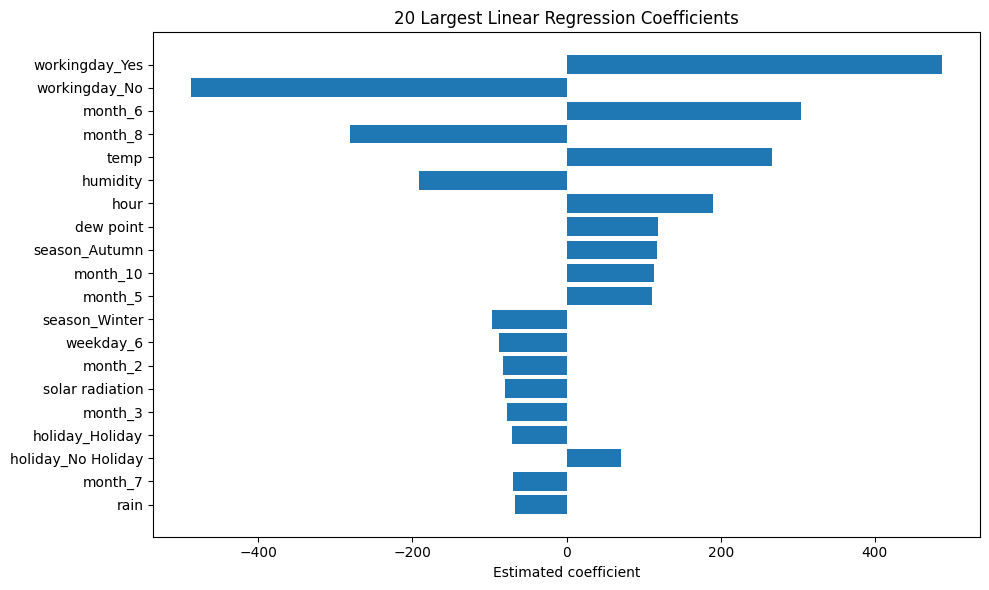

,RMSE,MAE,R2
Linear Regression,419.600000,316.320000,0.577000


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ordinary Least Squares regression

ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

y_pred_ols = ols_model.predict(X_test)

coef_table = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": ols_model.coef_.ravel()
    })
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .drop(columns="abs_coefficient")
)

print("Estimated regression coefficients:")
print(coef_table)

top_coef = (
    coef_table.reindex(coef_table["coefficient"].abs().sort_values().index)
    .tail(20)
)

plt.figure(figsize=(10, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.xlabel("Estimated coefficient")
plt.title("20 Largest Linear Regression Coefficients")
plt.tight_layout()
plt.show()

rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
mae_ols = mean_absolute_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

results = pd.DataFrame(columns=["RMSE", "MAE", "R2"])
results.loc["Linear Regression"] = [
    round(rmse_ols, 2),
    round(mae_ols, 2),
    round(r2_ols, 3)
]

display(results.style.background_gradient(cmap="viridis", axis=0))

Workingday_Yes has coefficient 487.68 meaning rentals increase significantly on working days.
Month 6 which is June has coefficient 304.72 meaning that there is higher rental activity that month.
This drops in month 8 (august) which has coefficient -280.97.
Temperature has coefficient 267.19 meaning warmer weather increases the rental activity.
Humidity has coefficient -191.59 meaning that when it gets more humid there will be fewer rentals.
Hour has coefficient 189.94 and thus the rentals increase throughout the day.


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Optimal parameter values:
{'C': 100, 'epsilon': 0.1, 'kernel': 'linear'}

Estimated SVR coefficients:
               feature  coefficient
26      workingday_Yes   453.566700
25       workingday_No  -453.566700
5            dew point   338.873085
32             month_6   255.510115
2             humidity  -251.748434
34             month_8  -246.082994
0                 hour   136.098062
36            month_10   122.191248
19       season_Autumn   115.205222
31             month_5    89.059555
22       season_Winter   -79.226848
33             month_7   -75.768599
7                 rain   -69.038334
28             month_2   -68.780222
29             month_3   -67.316366
21       season_Summer   -66.341479
45           weekday_6   -52.164279
24  holiday_No Holiday    48.159113
23     holiday_Holiday   -48.159113
1                 temp    44.416031
43           weekday_4    41.751101
6      solar radiation   -41.567425
35       

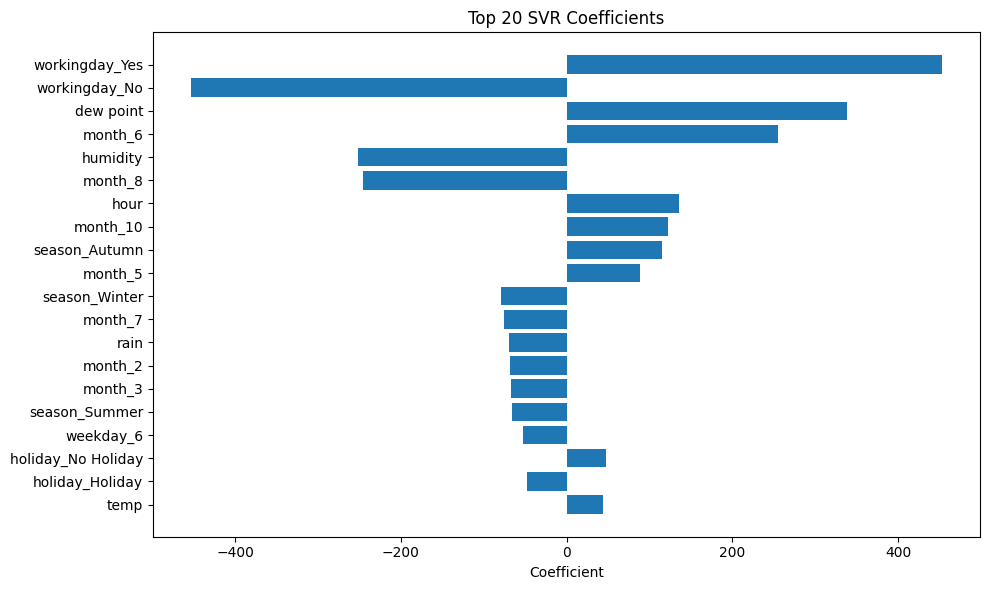

,RMSE,MAE,R2
Linear Regression,419.600000,316.320000,0.577000
SVR,433.330000,305.470000,0.549000


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Support Vector Regression with cross-validation

svr_model = SVR()

svr_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "kernel": ["linear"]
}

svr_search = GridSearchCV(
    estimator=svr_model,
    param_grid=svr_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

svr_search.fit(X_train, y_train.to_numpy())

svr_best = svr_search.best_estimator_

print("Optimal parameter values:")
print(svr_search.best_params_)

# Collect coefficients in a table
svr_coef_table = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": svr_best.coef_.ravel()
    })
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

print("\nEstimated SVR coefficients:")
print(svr_coef_table[["feature", "coefficient"]])

# Plot 20 largest coefficients by absolute size
top_svr = (
    svr_coef_table
    .sort_values("abs_coefficient")
    .tail(20)
)

plt.figure(figsize=(10, 6))
plt.barh(top_svr["feature"], top_svr["coefficient"])
plt.xlabel("Coefficient")
plt.title("Top 20 SVR Coefficients")
plt.tight_layout()
plt.show()

# Predictions and evaluation
y_pred_svr = svr_best.predict(X_test)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

results.loc["SVR"] = [
    round(rmse_svr, 2),
    round(mae_svr, 2),
    round(r2_svr, 3)
]

display(results.style.background_gradient(cmap="viridis", axis=0))

Workingday_Yes has coefficient 453.57 meaning that rentals increase significantly on working days, just like linear regression. Here dew point has a coefficient of 338.87. A high dew point increases the rentals with a stronger effect than the linear regression model. Similar to linear regression June (255.51) has a positive effect and August (-246.08) a negative effect. Humidity (-251.75) has a stronger negative effect on rentals than linear regression. Hour (136.10) means that rentals still increase throughout the day but not as strongly as in linear regression. Interestingly, temperature has a coeffiencient of 44.02 which is significantly lower than in linear regression.

In [41]:
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd

ebm = ExplainableBoostingRegressor(random_state=42)
param_grid_ebm = {'max_bins':[128, 256], 'max_interaction_bins': [16, 32], 'interactions': [5, 10, 15], 'learning_rate':[0.01, 0.03, 0.05]}

grid_search_ebm = GridSearchCV(ebm, param_grid_ebm, cv=stratified_kfold.split(X_train, training_cluster_numbers), scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1)
grid_search_ebm.fit(X_train, y_train)

print("Best parameters:", grid_search_ebm.best_params_)
print("Best RMSE:", np.sqrt(-grid_search_ebm.best_score_).round(2))

Best parameters: {'interactions': 15, 'learning_rate': 0.01, 'max_bins': 256, 'max_interaction_bins': 32}
Best RMSE: 240.75


## Comparison of models

Blackbox model XGBoost has the best permformance with highest R^2 (0.94), lowest RMSE (154.22), lowest MAE (86.41)

Random Forest comes closest to XGBoost with an R^2 of 0.92, an RMSE of 181.6 and an MAE of 104.11.

EBM had an R^2 of 0.86, RMSE of 244.96 and MAE of 167.21. Making it a balanced, reliable and interpretable model.

Rule fit has a slightly lower R^2 of 0.82 and higher RMSE (275.89) and MAE (190.26) than EBM.

Linear regression performed signficantly worse than these models with an R^2 of 0.58, RMSE of 419.60 and MAE of 316.32. Linear regression does not capture the patterns well in this data.

Similarly SVR performs poorly too with an R^2 of 0.55, RMSE of 433.33 and MAE of 305.47. Suggesting that it is not suited for this task either.

We conclude that XGBoost is the best model for performance. EBM and rule fit are preferres when interpretability is important. Both linear regression and SVR are not recommended. These results are in line with the accuracy interpretability trade off that we have seen in the lecture.